# NISAR Tutorial 3.3 — GSLC and GUNW, End to End

Two NISAR product levels applied to the same 24 June 2026 earthquake, then validated against an independent damage estimate.

| Part | Product | What you do |
|---|---|---|
| **1** | **GSLC** (Track 054, descending, Frame 083) | Build an interferogram from geocoded complex imagery: multi-look it, count fringes for displacement, then form pre- and post-event coherence and difference them. |
| **2** | **GUNW** (Track 162, ascending, Frame 007) | Read a *finished* product: unwrapped phase, coherence, and the same coherence-difference calculation — but with the interferometry already done for you. |
| **3** | **DPM** | Compare the GUNW coherence difference against a Damage Proxy Map and score the agreement with a confusion matrix. |

**Why both product levels.** GSLC is the raw ingredient — phase-preserving complex imagery that has not yet been turned into anything. GUNW is the finished good. Part 1 shows you what the processor actually does; Part 2 shows you what you get when someone else has done it. Doing them in this order means that when you read `unwrappedPhase` out of a GUNW file in Part 2, you know exactly what produced it.

This is a modified notebook from the ISCE Plus course. Copyright (c) 2026, ISCE+
If you are interested in NISAR and the ISCE Plus course, this is the website: https://github.com/isceplus/2026-isceplus


## Contents

**Part 1 — GSLC**
- [0.1 Setup](#0.1) · [0.2 Downloading the Data](#0.2)
- [1. HDF5 Structure](#1)
- [2. Reading the Cropped Data](#2)
- [3. Interferogram Formation — Event Pair (5 Jun → 29 Jun)](#3) · [3.1 Multi-Looking](#3.1) · [3.2 Counting Fringes](#3.2)
- [4. Pre-Event Coherence (24 May → 5 Jun)](#4)
- [5. Post-Event Coherence (5 Jun → 29 Jun)](#5)
- [6. Coherence Difference (Pre − Post)](#6)

**Part 2 — GUNW** *(sections renumbered in place; see the Part 2 header)*

**Part 3 — Validation against the Damage Proxy Map**
- [7.1 Export and download the GUNW coherence difference](#7.1)
- [7.2 Crop both rasters to the same extent](#7.2)
- [7.3 Upload your cropped rasters](#7.3)
- [7.4 Thresholds and statistics](#7.4) · [7.5 Try it yourself](#7.5)



<a id="0.1"></a>
## 0.1 Setup

In [37]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED = {                      # import name -> pip name
    "rasterio": "rasterio",
    "psutil": "psutil",           # used by the ram() memory probe
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("Environment ready - nothing to install.")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = Path('.')
if IN_COLAB:
    print(f"Colab detected - data will be read/written under {DATA_DIR.resolve()} "
          f"(Colab's local disk - ephemeral, wiped on runtime reset).")
else:
    print(f"Data will be read/written under {DATA_DIR.resolve()}.")

Environment ready - nothing to install.
Colab detected - data will be read/written under /content (Colab's local disk - ephemeral, wiped on runtime reset).


In [38]:
import os
import gc
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)


# ------------------------------- memory helpers -------------------------------
# Colab's standard runtime is killed at ~12.7 GB RSS. At STRIDE=3 one GSLC array
# is ~0.67 GB and one coherence map is ~0.34 GB, so the budget is real.

def ram(label=""):
    """Print current process memory (RSS). Call it after any heavy cell."""
    try:
        import psutil
        rss = psutil.Process(os.getpid()).memory_info().rss / 1e9
        print(f"[RAM] {rss:5.2f} GB   {label}")
    except Exception:
        pass


def free(*names):
    """Drop the named globals if they exist, then collect.

    Safe to call for names that were never defined, so cells stay re-runnable in
    any order. Note that the `del` is what actually frees the memory: CPython
    releases an array the moment its last reference goes away. gc.collect() only
    reclaims reference cycles, which the numpy arrays here never form - it is
    here for tidiness, not because it is what lowers your peak.
    """
    g = globals()
    for n in names:
        if n in g:
            del g[n]
    gc.collect()


DISPLAY_MAX_PIXELS = 4_000_000

def dec(a):
    """Decimate a large array for display, returning a strided VIEW (no copy).

    imshow resamples to screen resolution anyway, so handing it an 84-megapixel
    array just makes matplotlib allocate an 84-megapixel float copy of it for no
    visible benefit. Arrays already under DISPLAY_MAX_PIXELS pass through.
    """
    n = max(1, int(np.ceil(np.sqrt(a.size / DISPLAY_MAX_PIXELS))))
    return a[::n, ::n]


ram("after imports")

[RAM]  1.81 GB   after imports


<a id="0.2"></a>
## 0.2 Downloading the Data

These are the small, already-cropped `.h5` files hosted on our own bucket — no Earthdata Login required, since we're not downloading from ASF directly. **Edit the three URLs below to your actual bucket links.**

In [39]:
import gc
# --- Edit these three URLs to your actual AWS bucket links ---
BUCKET_URLS = {
    "may24": "https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/gslc_cropped_may24.h5",
    "jun05": "https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/gslc_cropped_jun05.h5",
    "jun29": "https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/gslc_cropped_jun29.h5",
}

!wget -c {BUCKET_URLS["may24"]} -P {DATA_DIR}
!wget -c {BUCKET_URLS["jun05"]} -P {DATA_DIR}
!wget -c {BUCKET_URLS["jun29"]} -P {DATA_DIR}

gslc_may24 = DATA_DIR / "gslc_cropped_may24.h5"
gslc_jun05 = DATA_DIR / "gslc_cropped_jun05.h5"
gslc_jun29 = DATA_DIR / "gslc_cropped_jun29.h5"

for label, f in [("may24", gslc_may24), ("jun05", gslc_jun05), ("jun29", gslc_jun29)]:
    if f.exists():
        print(f"Found ({label}): {f}  ({f.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"Not found ({label}): {f} - uncomment and run the wget lines above first.")

gc.collect()

--2026-09-30 09:51:58--  https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/gslc_cropped_may24.h5
Resolving eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com (eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com)... 3.5.151.104, 52.219.132.95, 3.5.149.152, ...
Connecting to eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com (eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com)|3.5.151.104|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.

--2026-09-30 09:51:59--  https://eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com/tutorial_3/gslc_cropped_jun05.h5
Resolving eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com (eyes-on-earth-tutorial-resources.s3.ap-southeast-1.amazonaws.com)... 3.5.151.104, 52.219.132.95, 3.5.149.152, ...
Connecting to eyes-on-earth-tutorial-resources.

49286

<a id="1"></a>
## 1. HDF5 Structure

Before touching any pixels, look at what's actually in the file. These cropped granules keep the **same internal layout as a full NISAR GSLC product** — they are just cut down to a smaller spatial extent than the ~20–40 GB original.

Things worth noticing as you read the tree below:

- Everything lives under `/science/LSAR/`, split into `GSLC/` (the data) and `identification/` (who/when/where).
- The image arrays are at `/science/LSAR/GSLC/grids/frequencyA/<polarization>` and are **complex** (`complex64`) — amplitude *and* phase in one array. That's what makes interferometry possible.
- `xCoordinates` / `yCoordinates` give the map grid (UTM easting/northing in metres). Because GSLC products for the same track and frame are geocoded to a **common grid**, the three dates line up pixel-for-pixel with no coregistration step — this is the whole reason CCD is easy with GSLC.
- `GSLC/metadata/` holds the geolocation and calibration cubes.



In [40]:
def print_hdf5_structure(node, name='/', depth=0, max_depth=4):
    """Recursively print an HDF5 hierarchy: groups as `name/`, datasets with shape and dtype."""
    pad = '  ' * depth
    if isinstance(node, h5py.Group):
        print(f"{pad}{name}/")
        if depth >= max_depth:
            if len(node):
                print(f"{pad}  ... {len(node)} item(s) below this level not shown")
            return
        for key in node:
            print_hdf5_structure(node[key], key, depth + 1, max_depth)
    else:
        print(f"{pad}{name}   shape={node.shape}, dtype={node.dtype}")


# EDIT ME: how deep to walk the tree.
#   4 reaches the image arrays under grids/frequencyA
#   6-8 also unrolls the metadata cubes, orbit and processingInformation groups
MAX_DEPTH = 4

with h5py.File(gslc_jun05, 'r') as f:
    print(f"=== HDF5 structure of {gslc_jun05.name} (max_depth={MAX_DEPTH}) ===")
    print_hdf5_structure(f, '/', 0, MAX_DEPTH)

    print("\n=== /science/LSAR/identification ===")
    ident = f['/science/LSAR/identification']
    for key in ident:
        obj = ident[key]
        if not isinstance(obj, h5py.Dataset):
            continue
        val = obj[()]
        if isinstance(val, bytes):
            val = val.decode('utf-8', 'replace')
        print(f"  {key:38s}: {val}")

    print("\n=== /science/LSAR/GSLC/grids/frequencyA ===")
    grid = f['/science/LSAR/GSLC/grids/frequencyA']
    pols = [k for k in grid if isinstance(grid[k], h5py.Dataset) and grid[k].dtype.kind in 'cV'
            and grid[k].ndim == 2]
    print(f"  2-D image layers : {pols}")
    for p in pols:
        print(f"    {p}: shape={grid[p].shape}, dtype={grid[p].dtype}")
    x, y = grid['xCoordinates'][:], grid['yCoordinates'][:]
    print(f"  X (easting)      : {x[0]:.1f} -> {x[-1]:.1f} m,  spacing {np.mean(np.diff(x)):.1f} m")
    print(f"  Y (northing)     : {y[0]:.1f} -> {y[-1]:.1f} m,  spacing {np.mean(np.diff(y)):.1f} m")
    print(f"  grid size        : {len(y)} rows x {len(x)} cols")

=== HDF5 structure of gslc_cropped_jun05.h5 (max_depth=4) ===
//
  science/
    LSAR/
      GSLC/
        grids/
          ... 1 item(s) below this level not shown
      identification/
        absoluteOrbitNumber   shape=(), dtype=uint32
        boundingPolygon   shape=(), dtype=|S2149
        compositeReleaseId   shape=(), dtype=|S6
        diagnosticModeFlag   shape=(), dtype=uint32
        frameNumber   shape=(), dtype=uint16
        granuleId   shape=(), dtype=|S91
        hasInputDataException   shape=(), dtype=uint8
        instrumentName   shape=(), dtype=|S4
        isDithered   shape=(), dtype=|S4
        isFullFrame   shape=(), dtype=|S4
        isGeocoded   shape=(), dtype=|S4
        isJointObservation   shape=(), dtype=|S5
        isMixedMode   shape=(), dtype=|S5
        isUrgentObservation   shape=(), dtype=|S5
        listOfFrequencies   shape=(2,), dtype=|S1
        listOfObservationModes   shape=(1,), dtype=|S15
        lookDirection   shape=(), dtype=|S4
        mis

<a id="2"></a>
## 2. Reading the Cropped Data

These files are already cropped to the bounding box, so no spatial subsetting is needed — but the full `HH` array is still large, so we read it with a **stride** (take every *n*-th pixel) to keep three dates in memory at once.

`STRIDE` is a decimation factor, *not* multi-looking: striding throws pixels away and keeps the speckle, multi-looking (Section 3) averages them and suppresses it. Memory scales as `1/STRIDE²`.

In [41]:
def read_gslc_cropped(h5_file, frequency='frequencyA', polarization='HH', subset=None, stride=(1, 1)):
    with h5py.File(h5_file, 'r') as f:
        grid = f[f'/science/LSAR/GSLC/grids/{frequency}']
        dataset = grid[polarization]
        full_shape = dataset.shape

        if subset is None:
            row_slice = slice(None, None, stride[0])
            col_slice = slice(None, None, stride[1])
        else:
            row_slice = slice(subset[0][0], subset[0][1], stride[0])
            col_slice = slice(subset[1][0], subset[1][1], stride[1])

        data = dataset[row_slice, col_slice]

        x_coords_full = grid['xCoordinates'][:]
        y_coords_full = grid['yCoordinates'][:]
        if subset is None:
            x_coords = x_coords_full[::stride[1]]
            y_coords = y_coords_full[::stride[0]]
        else:
            x_coords = x_coords_full[subset[1][0]:subset[1][1]:stride[1]]
            y_coords = y_coords_full[subset[0][0]:subset[0][1]:stride[0]]

    return data, x_coords, y_coords, full_shape

In [42]:
# EDIT ME: stride=3 cuts memory ~9x (stride^2) versus full resolution.
# Raising it to 4 or 5 is by far the cheapest way to stay under 12.7 GB.
# Drop toward 1 only if you have plenty of RAM.
STRIDE = 3

slc_may24, x_coords, y_coords, _ = read_gslc_cropped(gslc_may24, stride=(STRIDE, STRIDE))
slc_jun05, _, _, _ = read_gslc_cropped(gslc_jun05, stride=(STRIDE, STRIDE))
slc_jun29, _, _, _ = read_gslc_cropped(gslc_jun29, stride=(STRIDE, STRIDE))
extent = [x_coords[0], x_coords[-1], y_coords[-1], y_coords[0]]

# Effective ground spacing of the arrays we now hold (native spacing x STRIDE)
PIXEL_X = abs(float(np.mean(np.diff(x_coords))))
PIXEL_Y = abs(float(np.mean(np.diff(y_coords))))

print(f"may24: shape={slc_may24.shape}")
print(f"jun05: shape={slc_jun05.shape}")
print(f"jun29: shape={slc_jun29.shape}")
print(f"pixel spacing after STRIDE={STRIDE}: {PIXEL_Y:.1f} m (north) x {PIXEL_X:.1f} m (east)")
print(f"memory per date: {slc_jun05.nbytes / 1e9:.2f} GB "
      f"-> {3 * slc_jun05.nbytes / 1e9:.2f} GB for all three")


ram("3 GSLC dates loaded")

may24: shape=(9010, 9308)
jun05: shape=(9010, 9308)
jun29: shape=(9010, 9308)
pixel spacing after STRIDE=3: 15.0 m (north) x 15.0 m (east)
memory per date: 0.67 GB -> 2.01 GB for all three
[RAM]  3.62 GB   3 GSLC dates loaded


<a id="3"></a>
## 3. Interferogram Formation — Event Pair (5 Jun → 29 Jun)

This is the **only** interferogram we form and display: the pair that straddles the 24 June 2026 doublet.

$$\text{Interferogram} = \text{GSLC}_{\text{5 Jun}} \times \text{GSLC}_{\text{29 Jun}}^{*}$$

$$\phi = \arg(\text{Interferogram})$$



In [49]:
def multilook(arr, window=(1, 1)):
    """Average `arr` in non-overlapping blocks of `window` = (az_looks, rg_looks).

    Works on complex interferograms (averaging real and imaginary parts together,
    which is what preserves the phase) as well as on real-valued arrays.
    """
    az_looks, rg_looks = window
    if (az_looks, rg_looks) == (1, 1):
        return arr
    out_rows, out_cols = arr.shape[0] // az_looks, arr.shape[1] // rg_looks
    trim = arr[:out_rows * az_looks, :out_cols * rg_looks]
    return trim.reshape(out_rows, az_looks, out_cols, rg_looks).mean(axis=(1, 3))


def form_interferogram(gslc1, gslc2, multilook_window=(1, 1)):
    """Form an interferogram from two GSLC arrays, with optional multi-looking."""
    return multilook(gslc1 * np.conj(gslc2), multilook_window)


# Event pair, full resolution. Held in memory so Section 3.1 can re-multi-look it
# instantly when you change the number of looks. That costs ~0.7 GB - if RAM is
# tight, uncomment the free() at the end of 3.1 and accept re-running this cell.
ifg_event = form_interferogram(slc_jun05, slc_jun29, multilook_window=(1, 1))
print(f"Event-pair interferogram: shape={ifg_event.shape}, dtype={ifg_event.dtype}, "
      f"{ifg_event.nbytes / 1e9:.2f} GB")

# dec() hands imshow a decimated view instead of 84 megapixels it cannot display.
ifg_amp = np.abs(dec(ifg_event))
lo, hi = np.percentile(ifg_amp, [2, 98])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

im1 = axes[0].imshow(np.angle(dec(ifg_event)), cmap='RdBu', aspect='auto', extent=extent,
                     vmin=-np.pi, vmax=np.pi)
axes[0].set_title('Interferogram Phase (5 Jun -> 29 Jun)')
axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], label='Phase (radians)')

im2 = axes[1].imshow(ifg_amp, cmap='gray', aspect='auto', extent=extent, vmin=lo, vmax=hi)
axes[1].set_title('Interferogram Amplitude (5 Jun -> 29 Jun)')
axes[1].set_xlabel('Easting (m)')
plt.colorbar(im2, ax=axes[1], label='Amplitude')

plt.tight_layout(); plt.show()

free('ifg_amp')
ram("Section 3 done (full-res interferogram still held)")

NameError: name 'slc_jun05' is not defined

<a id="3.1"></a>
### 3.1 Multi-Looking — *edit the parameters and re-run*

SAR interferograms are inherently noisy at full resolution — each pixel's phase is the coherent sum of scattering from many small features inside that resolution cell (buildings, rocks, vegetation), which produces **speckle**: a grainy, salt-and-pepper pattern of essentially random phase jumps between neighbouring pixels, sitting on top of the real interferometric signal.

**Multi-looking** reduces this by averaging a block of adjacent pixels into one output pixel, trading spatial resolution for a cleaner signal. A "5×5 multi-look window" means averaging 5 pixels in azimuth (along-track) × 5 pixels in range (cross-track) = **25 looks** per output pixel; a "1×1 window" is 1 look, i.e. no averaging at all (full resolution, noisiest).

In real data the pixels aren't perfectly independent (neighbouring pixels share energy through the sensor's point-spread function, and this data has already been strided), so the *effective* noise reduction is somewhat less than that idealised estimate — but the direction of the tradeoff (more looks = smoother but coarser) always holds.

**Your turn.** `AZ_LOOKS` and `RG_LOOKS` in the cell below are meant to be edited. Re-running is cheap, the full-resolution interferogram is already in memory, so the cell only re-averages it. Try `(1,1)`, `(2,2)`, `(5,5)`, `(10,10)`, `(20,20)`, and something like `(5,15)`, and watch three numbers move together:

| Readout | What it tells you |
|---|---|
| output shape | how much resolution you gave up |
| pixel size (m) | the ground sampling of each output pixel |


 Watch for the point of diminishing returns: past a certain number of looks the roughness barely improves but you keep losing resolution — and once your output pixel is larger than the features you are trying to detect, you have over-smoothed.

> **Ask yourself:** what is the smallest feature you need to resolve in this scene (a collapsed building? a landslide scar? a whole city block?), and what does that imply for the largest window you can justify?

In [48]:
# ======================= EDIT ME =======================
# Looks averaged into each output pixel.
#   AZ_LOOKS -> pixels averaged in azimuth (rows / northing)
#   RG_LOOKS -> pixels averaged in range   (cols / easting)
# (1, 1) means no averaging at all. Try (2,2), (5,5), (10,10), (20,20), (5,15) ...
AZ_LOOKS = 5
RG_LOOKS = 5
# =======================================================

ifg_multi_looked = multilook(ifg_event, (AZ_LOOKS, RG_LOOKS))
n_looks = AZ_LOOKS * RG_LOOKS

print(f"{'':<22}{'shape':>20}{'pixel (m)':>18}")
print(f"{'full resolution':<22}{str(ifg_event.shape):>20}"
      f"{f'{PIXEL_Y:.0f} x {PIXEL_X:.0f}':>18}")
print(f"{f'{AZ_LOOKS}x{RG_LOOKS} = {n_looks} looks':<22}{str(ifg_multi_looked.shape):>20}"
      f"{f'{PIXEL_Y * AZ_LOOKS:.0f} x {PIXEL_X * RG_LOOKS:.0f}':>18}")


fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(np.angle(dec(ifg_event)), cmap='RdBu', aspect='equal', extent=extent,
               vmin=-np.pi, vmax=np.pi)
axes[0].set_title(f'Full-resolution phase (1 look)\n{PIXEL_Y:.0f} x {PIXEL_X:.0f} m pixels')
axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')

im2 = axes[1].imshow(np.angle(dec(ifg_multi_looked)), cmap='RdBu', aspect='equal', extent=extent,
                     vmin=-np.pi, vmax=np.pi)
axes[1].set_title(f'Multi-looked phase ({AZ_LOOKS}x{RG_LOOKS} = {n_looks} looks)\n'
                  f'{PIXEL_Y * AZ_LOOKS:.0f} x {PIXEL_X * RG_LOOKS:.0f} m pixels')
axes[1].set_xlabel('Easting (m)')
plt.colorbar(im2, ax=axes[1], label='radians')

plt.tight_layout(); plt.show()

# RAM tight? Uncomment to give back ~0.7 GB now. Re-running this cell afterwards
# needs Section 3 re-run first.
# free('ifg_event')
ram("Section 3.1 done")

NameError: name 'ifg_event' is not defined

<a id="3.2"></a>
### 3.2 Counting Fringes — How Much Did the Ground Move?

The multi-looked image above is not just a pretty pattern. Each colour cycle — each **fringe** — is a fixed amount of ground movement, so you can read displacement straight off the picture by counting.

**Why one fringe = $\lambda/2$.** Radar measures the *two-way* path: the pulse travels out to the ground and back. If a patch of ground moves $\lambda/2$ closer to the satellite, the round trip shortens by $2 \times \lambda/2 = \lambda$ — exactly one full wavelength — and the phase comes back to where it started. So the interferometric phase wraps once for every $\lambda/2$ of **line-of-sight** range change:

$$\Delta r_{\text{LOS}} = N_{\text{fringes}} \times \frac{\lambda}{2}$$

For NISAR's L-band radar, $\lambda \approx 23.8$ cm, so **one fringe ≈ 11.9 cm**. The cell below reads the centre frequency out of the product itself rather than trusting that number.

> **Why L-band matters here.** Sentinel-1 is C-band, $\lambda = 5.55$ cm, so one fringe is only 2.8 cm. The *same* earthquake produces about four times as many fringes at C-band, packed four times more tightly. Near a rupture they can pack so tightly that they can no longer be separated and the interferogram is unusable. L-band's coarser fringes are a large part of why NISAR can measure right up to a fault trace.

**How to count.** From the image attached, count the number of fringes across the two profiles, A and B. Every fringe you cross on the way in is $\lambda/2$ of displacement that has accumulated relative to the far field. Put your answer into the answer booklet provided.

**Three caveats worth stating before you quote a number:**

1. **Line-of-sight is not vertical, and not horizontal.** What you measure is the projection of the true 3-D displacement onto the radar look vector. Converting to actual ground motion needs the incidence angle *and* an assumption about which way the ground moved. A fringe count gives you $\Delta r_{\text{LOS}}$, not "the ground moved X cm up".
2. **The phase is not purely displacement.** It also carries atmospheric delay and any residual topographic error. Over tens of kilometres that is usually small compared with coseismic motion, but it is not zero.
3. **Fringes only mean anything in coherent ground.** If a profile crosses the decorrelated (noisy, speckled) part of the scene, the "fringes" there are random and any count through them is meaningless. Check your line against the coherence map before trusting it.



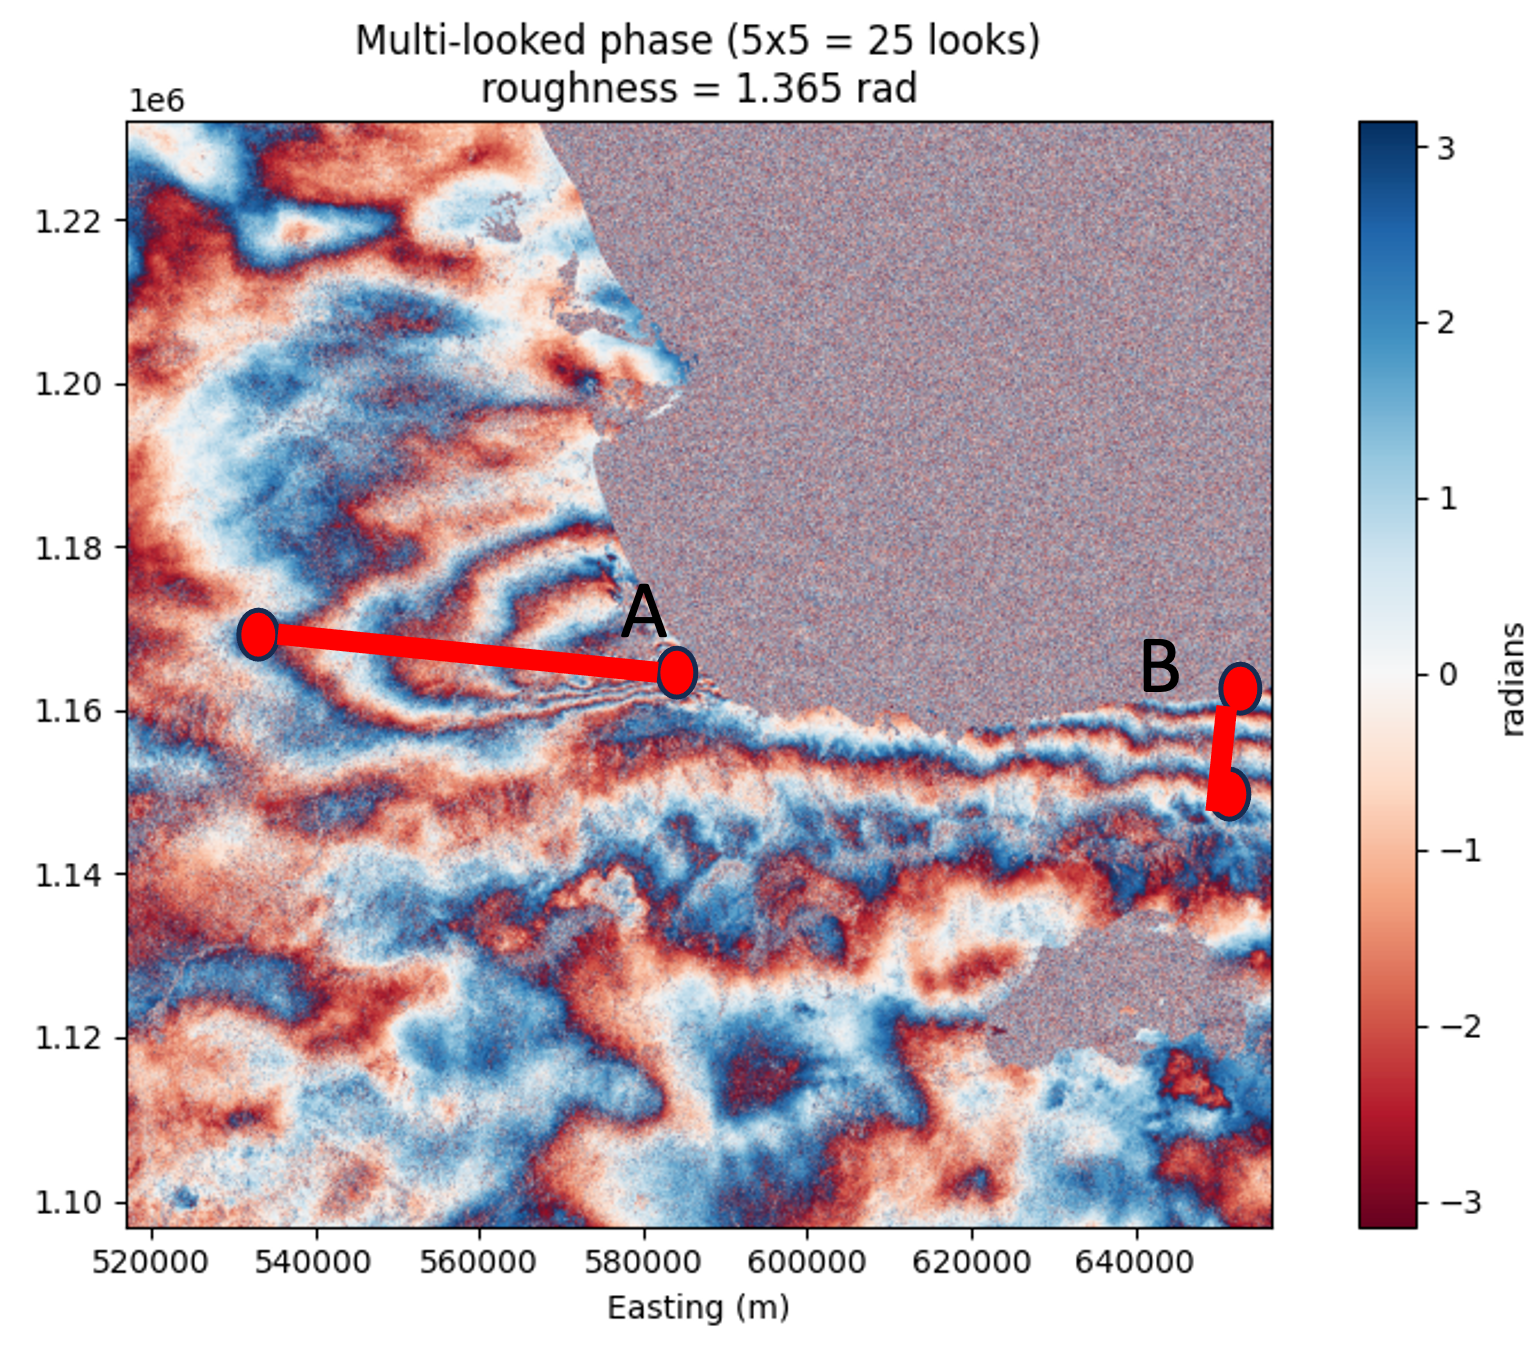

<a id="4"></a>
## 4. Pre-Event Coherence (24 May → 5 Jun)

$$\gamma = \frac{|\sum_{i=1}^{N} \text{SLC}_1^i \times (\text{SLC}_2^i)^*|}{\sqrt{\sum_{i=1}^{N} |\text{SLC}_1^i|^2 \times \sum_{i=1}^{N} |\text{SLC}_2^i|^2}}$$

[RAM]  3.71 GB   entering Section 4
Pre-event coherence: mean=0.373


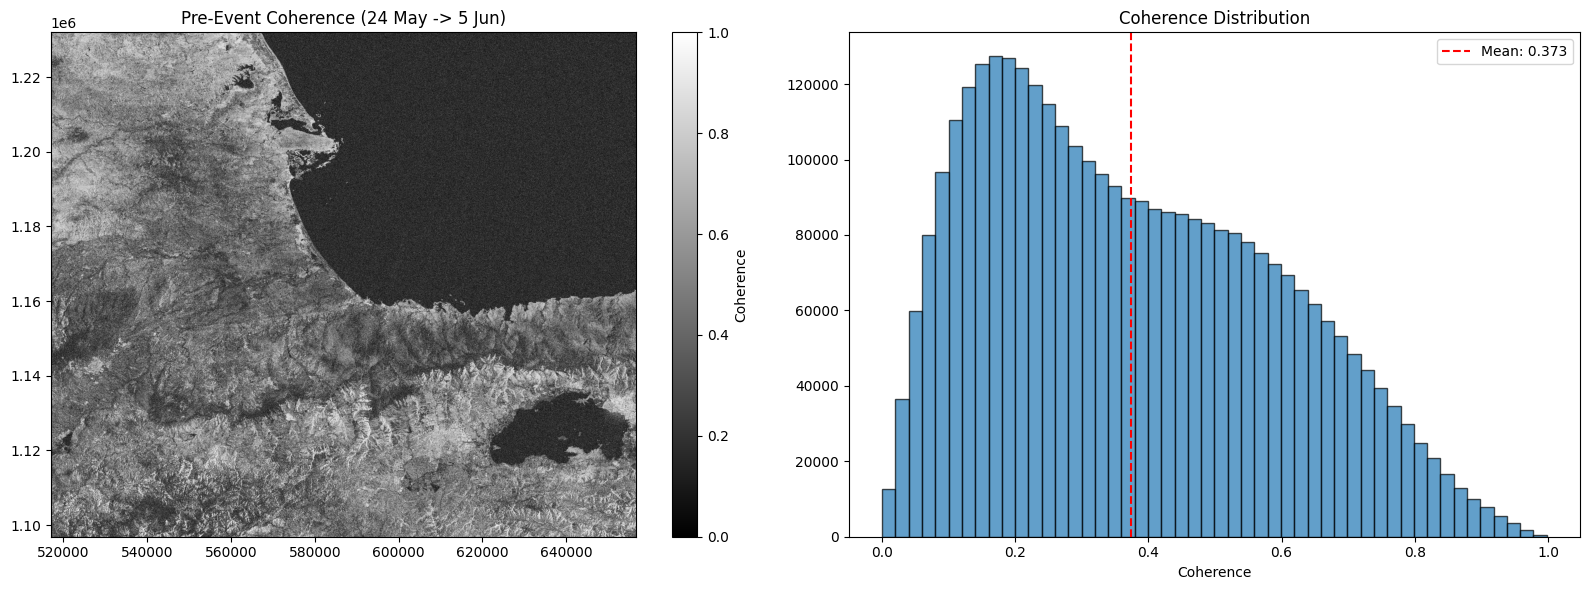

[RAM]  3.30 GB   Section 4 done (24 May freed)


In [45]:
# Section 3's interferograms are dead weight from here on, and coherence needs the RAM.
free('ifg_event', 'ifg_multi_looked')
ram("entering Section 4")


def calculate_coherence(slc1, slc2, window_size=(5, 5)):
    """Interferometric coherence, written to keep peak memory down.

    Identical maths to the textbook form, but it never builds a complex filtered
    array, does its arithmetic in place, and drops each full-size temporary the
    moment it dies. At STRIDE=3 that roughly halves the peak (~3.5 GB -> ~1.8 GB).
    """
    ifg = slc1 * np.conj(slc2)

    # |<s1 s2*>| via sqrt(re^2 + im^2), avoiding a complex64 intermediate
    num = ndimage.uniform_filter(np.real(ifg), size=window_size, mode='constant')
    num *= num
    tmp = ndimage.uniform_filter(np.imag(ifg), size=window_size, mode='constant')
    del ifg
    tmp *= tmp
    num += tmp
    del tmp
    np.sqrt(num, out=num)

    # sqrt(<|s1|^2> * <|s2|^2>)
    p = np.abs(slc1); p *= p
    den = ndimage.uniform_filter(p, size=window_size, mode='constant')
    p = np.abs(slc2); p *= p
    den *= ndimage.uniform_filter(p, size=window_size, mode='constant')
    del p
    np.sqrt(den, out=den)

    den += 1e-10
    num /= den
    del den
    return np.clip(num, 0, 1, out=num)


coherence_pre = calculate_coherence(slc_may24, slc_jun05, window_size=(5, 5))
print(f"Pre-event coherence: mean={coherence_pre.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(dec(coherence_pre), cmap='gray', vmin=0, vmax=1, aspect='auto', extent=extent)
axes[0].set_title('Pre-Event Coherence (24 May -> 5 Jun)')
plt.colorbar(im1, ax=axes[0], label='Coherence')
axes[1].hist(dec(coherence_pre).ravel(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(coherence_pre.mean(), color='red', linestyle='--',
                label=f'Mean: {coherence_pre.mean():.3f}')
axes[1].set_xlabel('Coherence'); axes[1].set_title('Coherence Distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

# Part 1 no longer needs 24 May - free it before the post-event coherence.
free('slc_may24')
ram("Section 4 done (24 May freed)")

<a id="5"></a>
## 5. Post-Event Coherence (5 Jun → 29 Jun)

This pair spans the 24 June 2026 doublet.

Post-event coherence: mean=0.317


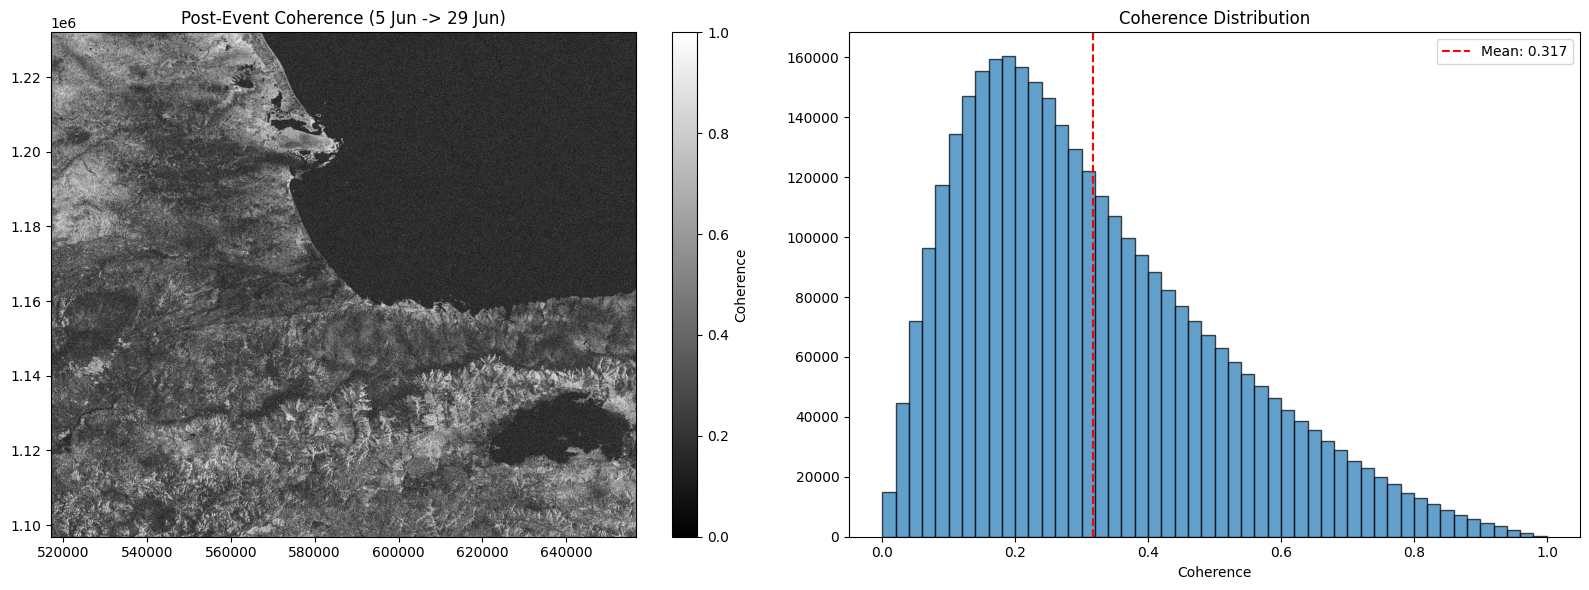

[RAM]  2.22 GB   Section 5 done (all full-resolution SLCs freed)


In [46]:
coherence_post = calculate_coherence(slc_jun05, slc_jun29, window_size=(5, 5))
print(f"Post-event coherence: mean={coherence_post.mean():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(dec(coherence_post), cmap='gray', vmin=0, vmax=1, aspect='auto', extent=extent)
axes[0].set_title('Post-Event Coherence (5 Jun -> 29 Jun)')
plt.colorbar(im1, ax=axes[0], label='Coherence')
axes[1].hist(dec(coherence_post).ravel(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(coherence_post.mean(), color='red', linestyle='--',
                label=f'Mean: {coherence_post.mean():.3f}')
axes[1].set_xlabel('Coherence'); axes[1].set_title('Coherence Distribution'); axes[1].legend()
plt.tight_layout(); plt.show()

# Part 1 is done with the SLCs - free them before Part 2 loads GUNW.
free('slc_jun05', 'slc_jun29')
ram("Section 5 done (all full-resolution SLCs freed)")

<a id="6"></a>
## 6. Coherence Difference (Pre − Post)

This is the Coherence Change Detection (CCD) technique. `coherence_pre` and `coherence_post` are already loaded and are the variables you will luse to calculate the coherence difference.

### Try it yourself

Fill in the one-line calculation below, then run the cell.

In [ ]:
# TODO: calculate the coherence difference, pre-event minus post-event, in one line.
# Positive values will mean coherence LOSS (pre was higher than post).
coherence_diff = None   # <-- replace this line

if coherence_diff is None:
    raise NotImplementedError("Fill in the coherence_diff calculation above, then re-run this cell.")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
im1 = axes[0].imshow(dec(coherence_pre), cmap='gray', vmin=0, vmax=1, aspect='auto', extent=extent)
axes[0].set_title('Pre-Event Coherence (24 May -> 5 Jun)'); plt.colorbar(im1, ax=axes[0], shrink=0.8)
im2 = axes[1].imshow(dec(coherence_post), cmap='gray', vmin=0, vmax=1, aspect='auto', extent=extent)
axes[1].set_title('Post-Event Coherence (5 Jun -> 29 Jun)'); plt.colorbar(im2, ax=axes[1], shrink=0.8)
vmax = float(np.nanpercentile(np.abs(dec(coherence_diff)), 98))
im3 = axes[2].imshow(dec(coherence_diff), cmap='RdBu_r', aspect='auto', extent=extent,
                     vmin=-vmax, vmax=vmax)
axes[2].set_title('Coherence Difference (Pre - Co)\nred: coherence loss')
plt.colorbar(im3, ax=axes[2], shrink=0.8)
plt.tight_layout(); plt.show()

print(f"Coherence difference: mean={coherence_diff.mean():.3f}, std={coherence_diff.std():.3f}")
ram("Section 6 done")

NotImplementedError: Fill in the coherence_diff calculation above, then re-run this cell.

---

# Part 2 — GUNW: Reading a Finished Product

Part 1 built an interferogram and a coherence map from GSLC by hand. Part 2 opens a **GUNW** product, where that work has already been done by the processor, and reads the results out: wrapped and unwrapped phase, coherence at two postings, and the correction layers.

Compare what you are about to do with what you just did. In Part 1 you wrote `gslc1 * np.conj(gslc2)` yourself and chose your own multi-look window and coherence window. In Part 2 those choices were made for you and baked into the file — which is convenient, and which is also why you should know what they were.

> **Heads up on the numbering.** Part 2 keeps the GUNW notebook's own section numbers and restarts at 0.1. A heading like "## 1. HDF5 Structure" below refers to the *GUNW* product, not to Part 1's Section 1.

> **Heads up on variable names.** The GUNW cells below re-use the names `coherence_pre`, `coherence_post` and `coherence_diff`. From here on those refer to the **GUNW** data, not Part 1's GSLC data. The cell below frees Part 1's arrays first — both to make that handover explicit and to give back the ~1 GB they occupy before the GUNW products load.

In [ ]:
# Hand over from Part 1 (GSLC) to Part 2 (GUNW).
#
# Part 1's arrays are not needed again: Part 3 validates the GUNW coherence
# difference, not the GSLC one. Freeing them here gives back roughly 1 GB and
# makes it explicit that `coherence_pre` / `coherence_post` / `coherence_diff`
# are about to be redefined with GUNW data.

for _name in ('coherence_pre', 'coherence_post', 'coherence_diff',
              'slc_may24', 'slc_jun05', 'slc_jun29',
              'ifg_event', 'ifg_multi_looked', 'coherence_diff_masked'):
    if _name in globals():
        del globals()[_name]
gc.collect()

try:
    ram("Part 1 released - starting Part 2 (GUNW)")
except NameError:
    print("Part 1 released - starting Part 2 (GUNW)")

# NISAR GUNW Explorer — Track 162 (Ascending), Frame 7

This tutorial explores the NISAR GUNW data directory. You will be able to plot and visualise the **wrapped interferogram**, the **unwrapped phase**, and the **coherence magnitude**, ending with a pre-event vs. post-event **coherence difference** exercise.

**Datasets** (both verified against the ASF/CMR granule catalogue), same track/frame, Pre event: 01 June -  13 June 2026, and Post event: 13 June 2026 - 25 June 2026:

| Role | Pair | Granule |
|---|---|---|
| Pre-event | 1 Jun → 13 Jun 2026 | `NISAR_L2_PR_GUNW_021_162_A_007_022_4000_SH_20260601T100657_20260601T100731_20260613T100656_20260613T100731_P05023_N_F_J_001.h5` |
| Post-event | 13 Jun → 25 Jun 2026 | `NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001.h5` |



## Table of Contents
- [0.1 Setup](#g0.1)
- [0.2 NASA Earthdata Login](#g0.2)
- [0.3 Downloading the Data](#g0.3)
- [1. HDF5 Structure](#g1)
- [2. Wrapped Interferogram (20 m posting)](#g2)
- [3. Unwrapped Phase (80 m posting)](#g3)
- [4. Post-Event Coherence Magnitude (13→25 Jun)](#g4)
- [5. Pre-Event Coherence Magnitude (1→13 Jun)](#g5)
- [6. Coherence Difference (Pre − Post)](#g6)

<a id="g0.1"></a>
## 0.1 Setup

Just run this cell, nothing to change.

In [1]:
import importlib.util
import subprocess
import sys
from pathlib import Path

REQUIRED = {                      # import name -> pip name
    "earthaccess": "earthaccess>=0.16",
}
missing = [pip for mod, pip in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("Environment ready - nothing to install.")

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

DATA_DIR = Path('.')
if IN_COLAB:
    print(f"Colab detected - data will be read/written under {DATA_DIR.resolve()} "
          f"(Colab's local disk - ephemeral, wiped on runtime reset).")
else:
    print(f"Data will be read/written under {DATA_DIR.resolve()}.")

Installing: earthaccess>=0.16
Colab detected - data will be read/written under /content (Colab's local disk - ephemeral, wiped on runtime reset).


In [2]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)

In [3]:
from pathlib import Path

OUTPUT_DIR = DATA_DIR / "output"
OUTPUT_DIR.mkdir(exist_ok=True)

def save_and_download(fig, filename):
    """Save a matplotlib figure as PNG into the output folder, and (in Colab) trigger a
    browser download - so you can just view/share a picture, no need to export a GeoTIFF
    and open it in QGIS."""
    out_path = OUTPUT_DIR / filename
    fig.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f"Saved {out_path}")
    if IN_COLAB:
        from google.colab import files
        files.download(str(out_path))

<a id="g0.2"></a>
## 0.2 NASA Earthdata Login

Reads your Earthdata username/password from Colab's **Secrets** (the key
icon in the left sidebar) - add two secrets named `EARTHDATA_USERNAME` and
`EARTHDATA_PASSWORD`, and toggle notebook access on for each. Nothing to
edit in the cell below.

In [4]:
import netrc
import stat
from pathlib import Path
import os

NETRC = Path.home() / ".netrc"

if IN_COLAB:
    from google.colab import userdata
    earthdata_user = userdata.get("EARTHDATA_USERNAME")
    earthdata_pass = userdata.get("EARTHDATA_PASSWORD")
else:
    from getpass import getpass
    earthdata_user = input("Earthdata username: ")
    earthdata_pass = getpass("Earthdata password: ")

def save_credentials(machine, login, password):
    """Add or replace one machine's line in ~/.netrc, leaving the others alone."""
    keep = []
    if NETRC.exists():
        for line in NETRC.read_text(encoding="utf-8").splitlines():
            fields = line.split()
            if not fields or fields[:2] == ["machine", machine]:
                continue
            keep.append(line)
    keep.append(f"machine {machine} login {login} password {password}")
    NETRC.write_text("\n".join(keep) + "\n", encoding="utf-8")
    if os.name != "nt":
        NETRC.chmod(stat.S_IRUSR | stat.S_IWUSR)

save_credentials("urs.earthdata.nasa.gov", earthdata_user, earthdata_pass)

import earthaccess
auth = earthaccess.login(strategy="netrc")
print("Authenticated:", auth.authenticated)

Authenticated: True


<a id="g0.3"></a>
## 0.3 Downloading the Data

GUNW products from NISAR contain geocoded, unwrapped phase, coherence, connected components, and associated metadata layers derived from SAR image pairs. It does not require users to process raw Single Look Complex (SLC) data.

NISAR data files are `.h5` (HDF5) files, not `.SAFE` (that's ESA/Copernicus's Sentinel packaging format). GUNW files are around ~2.2GB each to download.

In [5]:
# Uncomment to download

!wget -c https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_PROVISIONAL_V1/NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001/NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001.h5 -P {DATA_DIR}

!wget -c https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_PROVISIONAL_V1/NISAR_L2_PR_GUNW_021_162_A_007_022_4000_SH_20260601T100657_20260601T100731_20260613T100656_20260613T100731_P05023_N_F_J_001/NISAR_L2_PR_GUNW_021_162_A_007_022_4000_SH_20260601T100657_20260601T100731_20260613T100656_20260613T100731_P05023_N_F_J_001.h5 -P {DATA_DIR}

gunw_file = DATA_DIR / "NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001.h5"          # post-event: 13->25 Jun
gunw_file_pre = DATA_DIR / "NISAR_L2_PR_GUNW_021_162_A_007_022_4000_SH_20260601T100657_20260601T100731_20260613T100656_20260613T100731_P05023_N_F_J_001.h5"   # pre-event: 1->13 Jun

for label, f in [("post-event, 13->25 Jun", gunw_file), ("pre-event, 1->13 Jun", gunw_file_pre)]:
    if f.exists():
        print(f"Found ({label}): {f}  ({f.stat().st_size / (1024**3):.2f} GB)")
    else:
        print(f"Not found (download it first) ({label}): {f}")

--2026-10-06 08:36:11--  https://nisar.asf.earthdatacloud.nasa.gov/NISAR/NISAR_L2_GUNW_PROVISIONAL_V1/NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001/NISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001.h5
Resolving nisar.asf.earthdatacloud.nasa.gov (nisar.asf.earthdatacloud.nasa.gov)... 18.65.25.56, 18.65.25.11, 18.65.25.113, ...
Connecting to nisar.asf.earthdatacloud.nasa.gov (nisar.asf.earthdatacloud.nasa.gov)|18.65.25.56|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://urs.earthdata.nasa.gov/oauth/authorize?client_id=qpa3q_b7OJ32gGjwA9DxHg&response_type=code&redirect_uri=https://nisar.asf.earthdatacloud.nasa.gov/login&state=%2FNISAR%2FNISAR_L2_GUNW_PROVISIONAL_V1%2FNISAR_L2_PR_GUNW_022_162_A_007_023_4000_SH_20260613T100656_20260613T100731_20260625T100655_20260625T100730_P05023_N_F_J_001%2FNISAR_L2_PR

<a id="g1"></a>
## 1. HDF5 Structure

This breaks down the data in the GUNW product. This is with /metadata holding orbit, baseline, and processing parameters, and /science/.../interferogram containing the core raster datasets (unwrapped phase, coherence, connected components, amplitude)
```
/science/LSAR/GUNW/
  grids/frequencyA/
    wrappedInterferogram/HH/       # 20 m: wrappedInterferogram, coherenceMagnitude
    unwrappedInterferogram/HH/     # 80 m: unwrappedPhase, coherenceMagnitude, connectedComponents,
                                    #        ionospherePhaseScreen(+Uncertainty), mask
  metadata/radarGrid/                # 3D cubes: troposphereWet/Hydrostatic, solidEarthTide, ...
  metadata/processingInformation/    # inputs, algorithms, run configuration
```

In [6]:
def explore_hdf5_structure(filename, max_depth=4):
    def _print(name, obj, depth=0):
        if depth > max_depth:
            return
        if isinstance(obj, h5py.Group):
            tag = 'Group'
        elif isinstance(obj, h5py.Dataset):
            tag = f'Dataset {obj.shape} {obj.dtype}'
        else:
            tag = f'Datatype ({obj.dtype})'   # a named/committed HDF5 datatype - no shape, just a type definition
        print('  ' * depth + f"{name} ({tag})")
    with h5py.File(filename, 'r') as f:
        f.visititems(lambda n, o: _print(n, o, n.count('/')))

explore_hdf5_structure(gunw_file, max_depth=3)

complex64 (Datatype (complex64))
science (Group)
  science/LSAR (Group)
    science/LSAR/GUNW (Group)
      science/LSAR/GUNW/grids (Group)
      science/LSAR/GUNW/metadata (Group)
    science/LSAR/identification (Group)
      science/LSAR/identification/boundingPolygon (Dataset () |S2151)
      science/LSAR/identification/compositeReleaseId (Dataset () |S6)
      science/LSAR/identification/diagnosticModeFlag (Dataset () uint32)
      science/LSAR/identification/frameNumber (Dataset () uint16)
      science/LSAR/identification/granuleId (Dataset () |S123)
      science/LSAR/identification/instrumentName (Dataset () |S5)
      science/LSAR/identification/isDithered (Dataset () |S4)
      science/LSAR/identification/isFullFrame (Dataset () |S4)
      science/LSAR/identification/isGeocoded (Dataset () |S4)
      science/LSAR/identification/isMixedMode (Dataset () |S5)
      science/LSAR/identification/isUrgentObservation (Dataset () |S5)
      science/LSAR/identification/listOfFrequencie

<a id="g2"></a>
## 2. Wrapped Interferogram (20 m posting)

**Path:** `/science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/HH/wrappedInterferogram`

- **Data type:** complex64 (multi-looked at 30 m in range-Doppler, geocoded at 20 m)
- **Phase range:** −π to +π radians (this is the *raw*, not-yet-unwrapped fringe pattern)

Saved output/wrapped_interferogram_amplitude_phase.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

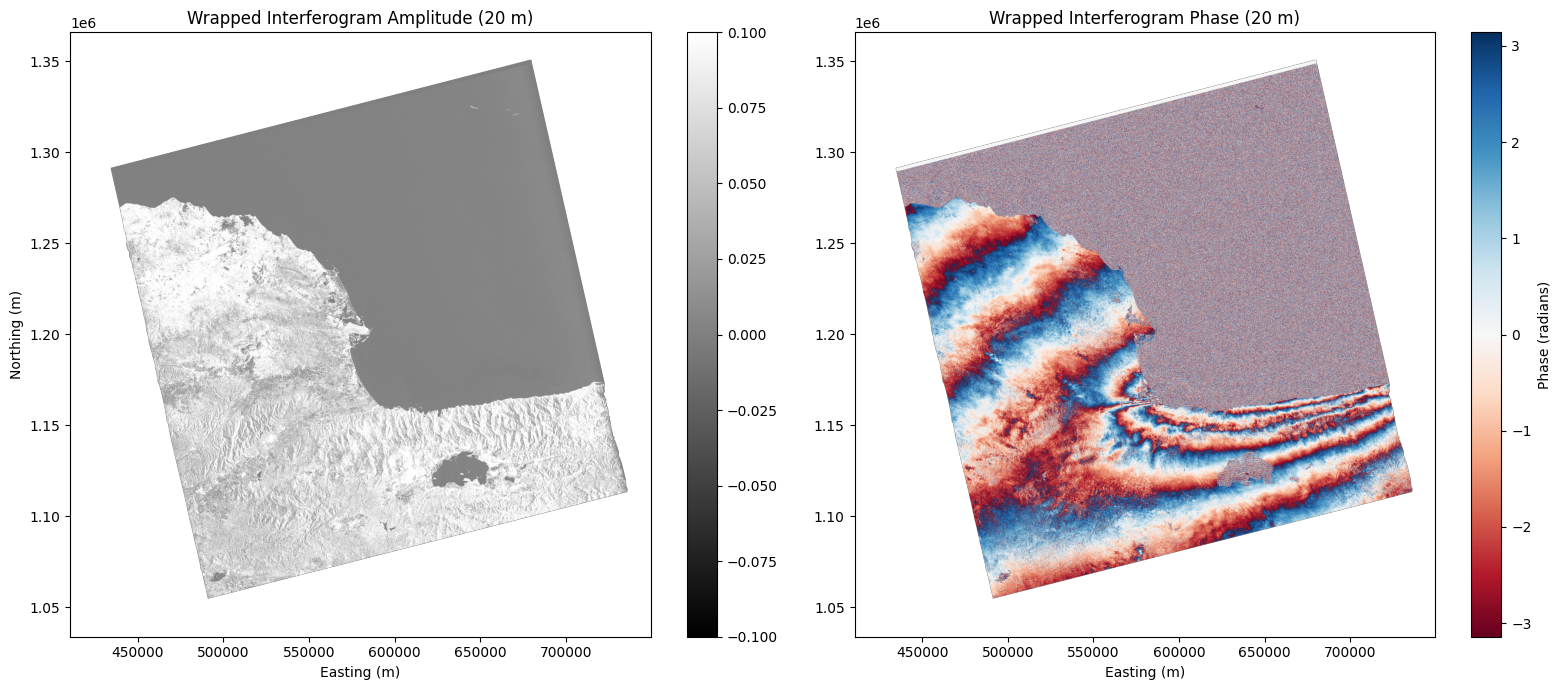

Wrapped interferogram shape: (3320, 3392)


101

In [7]:
import gc

def read_wrapped_interferogram(filename, polarization='HH', stride=1):
    with h5py.File(filename, 'r') as f:
        base = f'/science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/{polarization}'
        # stride is applied by h5py at the HDF5 read itself, not after loading the full array
        # into memory - so stride > 1 genuinely avoids materialising the full-res array.
        ifg = f[f'{base}/wrappedInterferogram'][::stride, ::stride]
        x = f[f'{base}/xCoordinates'][::stride]
        y = f[f'{base}/yCoordinates'][::stride]
    return ifg, x, y

# Default stride=5, not 1: at full 20 m resolution a whole GUNW frame's complex64 array can be
# several GB, which is enough to crash a Colab session's RAM. Only drop to stride=1 (full
# resolution) if you have enough memory and actually need the extra detail.
wrapped_ifg, wx, wy = read_wrapped_interferogram(gunw_file, stride=5)
wrapped_amplitude = np.abs(wrapped_ifg)
wrapped_phase = np.angle(wrapped_ifg)
wextent = [wx[0], wx[-1], wy[-1], wy[0]]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
im0 = axes[0].imshow(wrapped_amplitude, cmap='gray', aspect='auto', extent=wextent,
                      vmin=np.percentile(wrapped_amplitude, 2), vmax=np.percentile(wrapped_amplitude, 98))
axes[0].set_title('Wrapped Interferogram Amplitude (20 m)'); axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(wrapped_phase, cmap='RdBu', aspect='auto', extent=wextent, vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Wrapped Interferogram Phase (20 m)'); axes[1].set_xlabel('Easting (m)')
plt.colorbar(im1, ax=axes[1], label='Phase (radians)')
plt.tight_layout()
save_and_download(fig, "wrapped_interferogram_amplitude_phase.png")
plt.show()

print(f"Wrapped interferogram shape: {wrapped_ifg.shape}")

# wrapped_ifg (complex64, the biggest array here) is no longer needed once we have
# wrapped_amplitude/wrapped_phase for reference - free it explicitly rather than waiting on
# Python's own GC timing.
del wrapped_ifg
gc.collect()

<a id="g3"></a>
## 3. Unwrapped Phase (80 m posting)

**Path:** `/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/unwrappedPhase`

- **Sign convention:** positive phase = range increase (moving away from the sensor); negative = range decrease (moving toward the sensor).

Saved output/unwrapped_phase.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

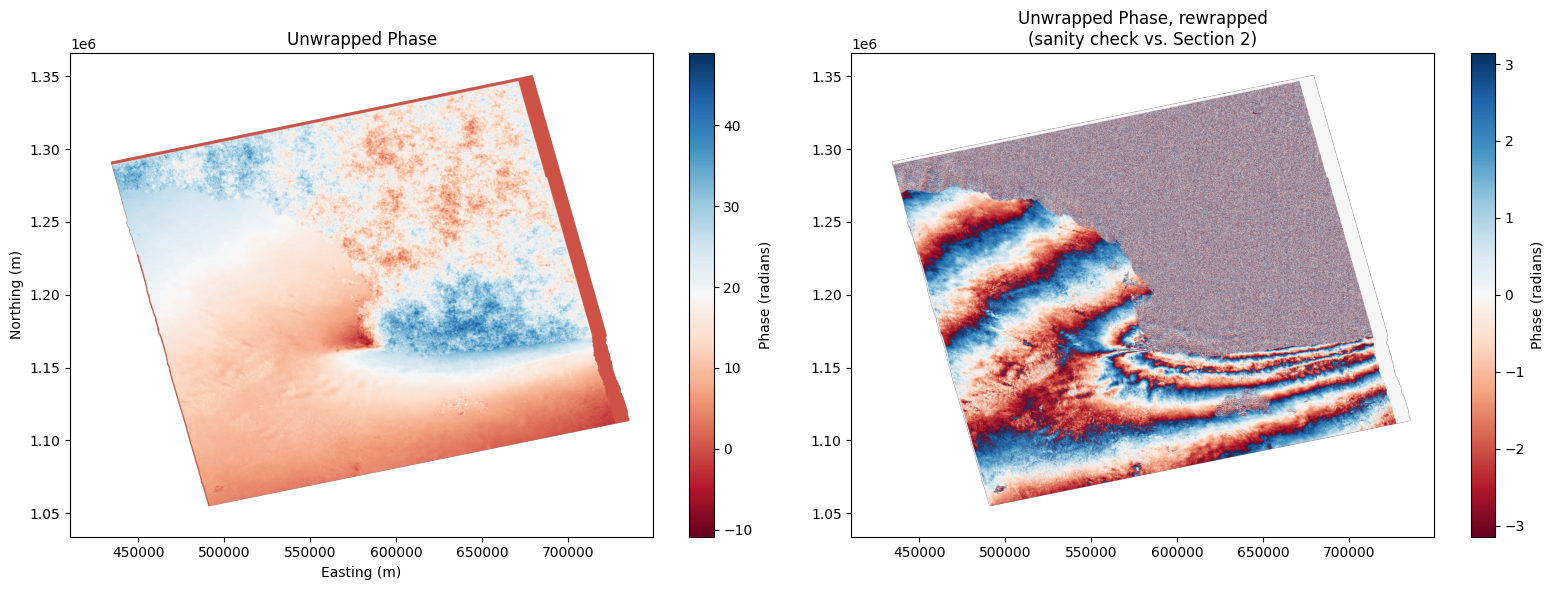

Unwrapped phase: shape=(4149, 4239), min=-10.85, max=48.90, mean=15.37 rad, valid pixels=54.6%


In [8]:
def read_unwrapped_phase(filename, polarization='HH'):
    with h5py.File(filename, 'r') as f:
        base = f'/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/{polarization}'
        phase = f[f'{base}/unwrappedPhase'][:]
        x = f[f'{base}/xCoordinates'][:]
        y = f[f'{base}/yCoordinates'][:]
    return phase, x, y

phase, gx, gy = read_unwrapped_phase(gunw_file)
gextent = [gx[0], gx[-1], gy[-1], gy[0]]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(phase, cmap='RdBu', aspect='auto', extent=gextent)
axes[0].set_title('Unwrapped Phase'); axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], label='Phase (radians)')

im2 = axes[1].imshow(np.angle(np.exp(1j * phase)), cmap='RdBu', aspect='auto', extent=gextent, vmin=-np.pi, vmax=np.pi)
axes[1].set_title('Unwrapped Phase, rewrapped\n(sanity check vs. Section 2)')
plt.colorbar(im2, ax=axes[1], label='Phase (radians)')
plt.tight_layout()
save_and_download(fig, "unwrapped_phase.png")
plt.show()

valid_phase = phase[~np.isnan(phase)]
print(f"Unwrapped phase: shape={phase.shape}, min={np.nanmin(phase):.2f}, max={np.nanmax(phase):.2f}, "
      f"mean={np.nanmean(phase):.2f} rad, valid pixels={100*len(valid_phase)/phase.size:.1f}%")

### 3.2 Measuring Earthquake Displacement from the Unwrapped Interferogram (TODO - Fill in Measurement Point lat / long)

Unlike the raw phase image above, unwrapped phase lets you convert directly into
displacement - as long as you're careful about what "directly" means. Phase is always
*relative*: you need a **reference point R** with a stable, undisturbed phase value
away from the deformation, which you define as zero. Everything else is then measured
relative to that.

**Reference point R** (given): **10.908674&deg; N, -69.029933&deg; E** - chosen further
from the fault, so you can compare it against a point closer to the visible
deformation and see how much bigger the phase (and displacement) gets.

**Measurement point M**: pick a point near the fault trace / visible fringe pattern in
the Section 3 plot above - but not right on top of the rupture itself, since
unwrapping often fails in the most decorrelated pixels there.

Fill in `LAT_M, LON_M` below, then run the cell.

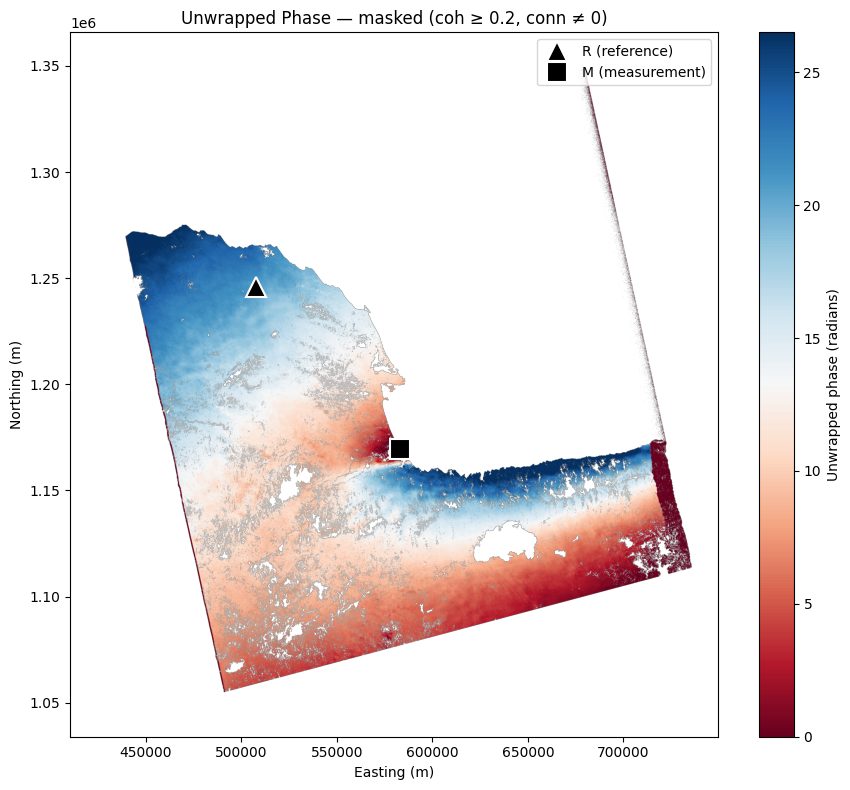

R: (11.2704794, -68.931352)  row=1499, col=1213,  phi_R = 21.244 rad
M: (10.581001, -68.24229)  row=2451, col=2156,  phi_M = -3.908 rad
delta_phi (M − R) = -25.152 rad
Estimated LOS displacement: 48.0 cm
Equivalent fringe count (delta_phi / 2π): -4.00


In [26]:
!pip install -q rasterio
from rasterio.warp import transform as rio_transform

WAVELENGTH = 0.24  # NISAR L-band, metres


def latlon_to_rowcol(lat, lon, x_coords, y_coords, epsg_code):
    (x,), (y,) = rio_transform("EPSG:4326", f"EPSG:{epsg_code}", [lon], [lat])
    col = int(np.argmin(np.abs(x_coords - x)))
    row = int(np.argmin(np.abs(y_coords - y)))
    return row, col


with h5py.File(gunw_file, "r") as f:
    epsg_gunw = int(f["/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/projection"][()])

    base = "/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH"

    # Connected-components map: 0 means the unwrapper left this pixel unresolved
    # (water, shadow, isolated region, etc.)
    conn = f[f"{base}/connectedComponents"][:]

    # Coherence (same group, 80 m posting)
    coh = f[f"{base}/coherenceMagnitude"][:]

    # Optional dedicated mask layer (1 = valid, 0 = invalid/water).
    # Not all product versions include this; we guard with a try.
    try:
        mask_layer = f[f"{base}/mask"][:]          # uint8, 1 = valid
        has_mask_layer = True
    except KeyError:
        has_mask_layer = False

# Build a combined boolean mask: True where the pixel is VALID
COHERENCE_THRESHOLD = 0.2      # discard incoherent pixels
valid = (conn != 0) & (coh >= COHERENCE_THRESHOLD)
if has_mask_layer:
    valid &= (mask_layer == 1)

# Apply to phase: NaN-out everything that failed the mask
phase_masked = np.where(valid, phase, np.nan)

# Reference and measurement points
LAT_R, LON_R = 11.2704794,-68.9313520

# TODO: pick a measurement point M near the fault trace / visible fringes and fill in below.
LAT_M, LON_M = None # <-- fill this in

if None in (LAT_M, LON_M):
    raise NotImplementedError("Error: go back and fill in LAT_M/LON_M above, then re-run this cell.")

ROW_R, COL_R = latlon_to_rowcol(LAT_R, LON_R, gx, gy, epsg_gunw)
ROW_M, COL_M = latlon_to_rowcol(LAT_M, LON_M, gx, gy, epsg_gunw)

phi_R = phase[ROW_R, COL_R]       # use unmasked phase for the exact point values
phi_M = phase[ROW_M, COL_M]
delta_phi = phi_M - phi_R

# ---- Plot: masked phase with R and M marked ----
fig, ax = plt.subplots(figsize=(9, 8))
im = ax.imshow(phase_masked, cmap="RdBu", aspect="auto", extent=gextent,
               vmin=np.nanpercentile(phase_masked, 2),   # stretch to 2–98th percentile
               vmax=np.nanpercentile(phase_masked, 98))  # so outliers don't blow the scale
plt.colorbar(im, ax=ax, label="Unwrapped phase (radians)")
ax.plot(gx[COL_R], gy[ROW_R], "k^", markersize=14, markeredgecolor="white",
        markeredgewidth=1.5, label="R (reference)")
ax.plot(gx[COL_M], gy[ROW_M], "ks", markersize=14, markeredgecolor="white",
        markeredgewidth=1.5, label="M (measurement)")
ax.legend()
ax.set_title(f"Unwrapped Phase — masked (coh ≥ {COHERENCE_THRESHOLD}, conn ≠ 0)")
ax.set_xlabel("Easting (m)"); ax.set_ylabel("Northing (m)")
plt.tight_layout()
#save_and_download(fig, "unwrapped_phase_R_M.png")
plt.show()

# ---- Displacement ----
print(f"R: ({LAT_R}, {LON_R})  row={ROW_R}, col={COL_R},  phi_R = {phi_R:.3f} rad")
print(f"M: ({LAT_M}, {LON_M})  row={ROW_M}, col={COL_M},  phi_M = {phi_M:.3f} rad")
print(f"delta_phi (M − R) = {delta_phi:.3f} rad")

displacement_m = -(WAVELENGTH / (4 * np.pi)) * delta_phi
n_fringes_equiv = delta_phi / (2 * np.pi)
print(f"Estimated LOS displacement: {displacement_m * 100:.1f} cm")
print(f"Equivalent fringe count (delta_phi / 2π): {n_fringes_equiv:.2f}")

# Warn if R or M fell on a masked pixel
if not valid[ROW_R, COL_R]:
    print("⚠️  WARNING: R landed on a masked pixel — consider moving it.")
if not valid[ROW_M, COL_M]:
    print("⚠️  WARNING: M landed on a masked pixel — phase value may be unreliable.")

<a id="g4"></a>
## 4. Post-Event Coherence Magnitude (13 → 25 Jun)

**Path:** `/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/coherenceMagnitude`

- **Range:** 0 (no correlation) to 1 (perfect correlation).

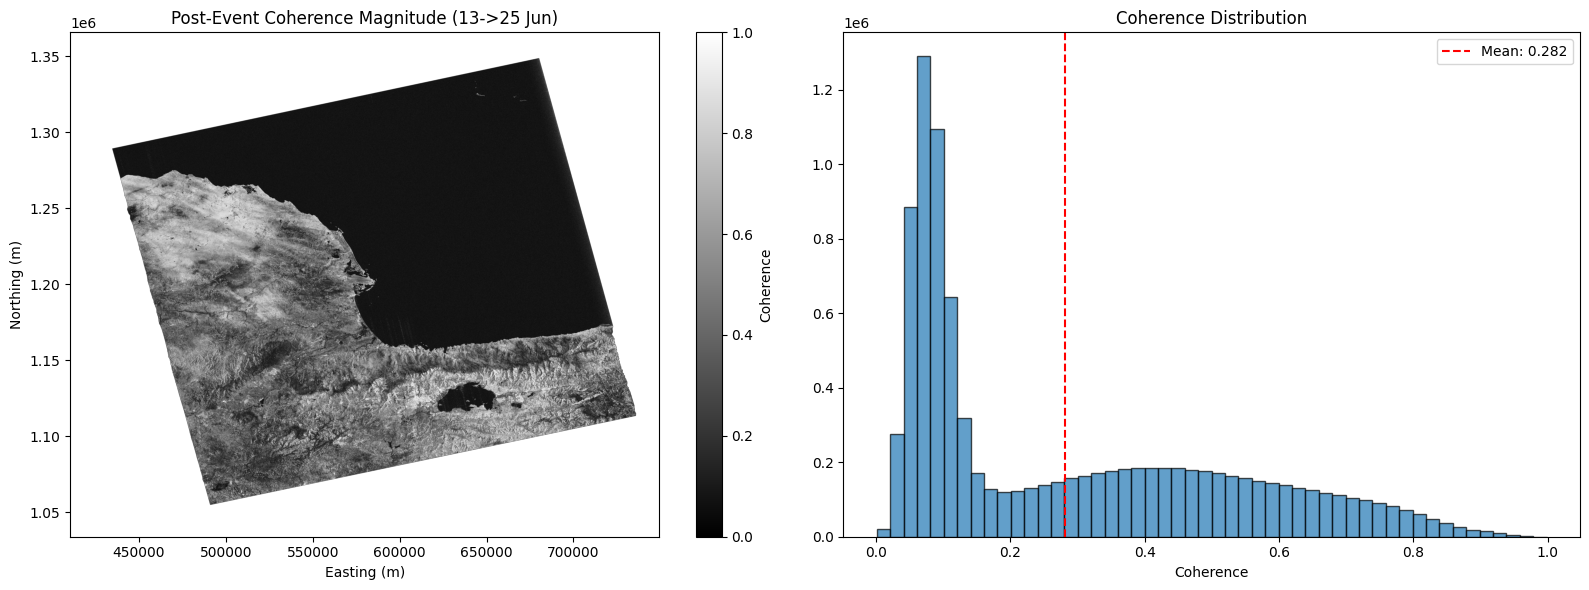

Post-event coherence: shape=(4149, 4239), mean=0.282, median=0.170


In [20]:
def read_coherence(filename, polarization='HH', posting='80m'):
    with h5py.File(filename, 'r') as f:
        base = (f'/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/{polarization}' if posting == '80m'
                else f'/science/LSAR/GUNW/grids/frequencyA/wrappedInterferogram/{polarization}')
        coh = f[f'{base}/coherenceMagnitude'][:]
    return coh

coherence_post = read_coherence(gunw_file, posting='80m')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(coherence_post, cmap='gray', vmin=0, vmax=1, aspect='auto', extent=gextent)
axes[0].set_title('Post-Event Coherence Magnitude (13->25 Jun)'); axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], label='Coherence')

axes[1].hist(coherence_post.ravel(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(np.nanmean(coherence_post), color='red', linestyle='--', label=f'Mean: {np.nanmean(coherence_post):.3f}')
axes[1].set_xlabel('Coherence'); axes[1].set_title('Coherence Distribution'); axes[1].legend()
plt.tight_layout()
#save_and_download(fig, "coherence_post_event.png")
plt.show()

print(f"Post-event coherence: shape={coherence_post.shape}, mean={np.nanmean(coherence_post):.3f}, median={np.nanmedian(coherence_post):.3f}")

<a id="g5"></a>
## 5. Pre-Event Coherence Magnitude (1 → 13 Jun)

Same read function, same 80 m posting, now applied to `gunw_file_pre` (the 1→13 Jun pair) instead of the post-event granule.

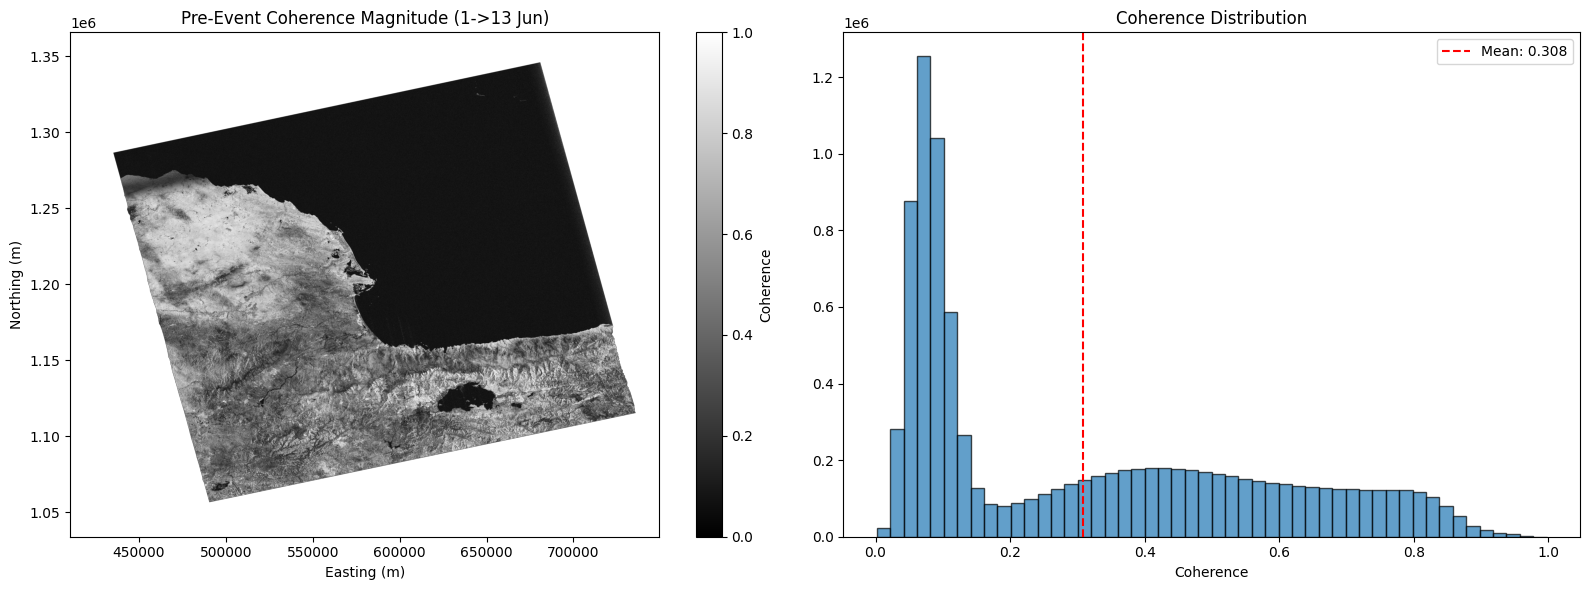

Pre-event coherence: shape=(4149, 4239), mean=0.308, median=0.212


In [21]:
coherence_pre = read_coherence(gunw_file_pre, posting='80m')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
im1 = axes[0].imshow(coherence_pre, cmap='gray', vmin=0, vmax=1, aspect='auto', extent=gextent)
axes[0].set_title('Pre-Event Coherence Magnitude (1->13 Jun)'); axes[0].set_xlabel('Easting (m)'); axes[0].set_ylabel('Northing (m)')
plt.colorbar(im1, ax=axes[0], label='Coherence')

axes[1].hist(coherence_pre.ravel(), bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(np.nanmean(coherence_pre), color='red', linestyle='--', label=f'Mean: {np.nanmean(coherence_pre):.3f}')
axes[1].set_xlabel('Coherence'); axes[1].set_title('Coherence Distribution'); axes[1].legend()
plt.tight_layout()
#save_and_download(fig, "coherence_pre_event.png")
plt.show()

print(f"Pre-event coherence: shape={coherence_pre.shape}, mean={np.nanmean(coherence_pre):.3f}, median={np.nanmedian(coherence_pre):.3f}")

<a id="g6"></a>
## 6. Coherence Difference (Pre - Post)

This is the Coherence Change Detection (CCD) technique from Tutorial 4, Section 4.2: comparing coherence *before* the 24 June 2026 doublet against coherence *after* it. A drop in coherence at a location that was stable pre-event is the classic damage-proxy signal — the pre-event pair (1→13 Jun) gives you a baseline for "what normal decorrelation looks like here," so a bigger drop in the post-event pair (13→25 Jun) stands out against that baseline rather than against an assumed coherence of 1.0.

`coherence_pre` and `coherence_post` are already loaded (Sections 4–5), same grid, same shape, just one line of arithmetic needed.

### Try it yourself (TODO - Fill in coherence_diff)

Fill in the one-line calculation below, then run the cell.

In [ ]:
# TODO: calculate the coherence difference, pre-event minus post-event, in one line. (Coherence_pre and Coherence_post)
coherence_diff = None # FILL THIS IN

if coherence_diff is None:
    raise NotImplementedError("Fill in the coherence_diff calculation above, then re-run this cell.")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
im1 = axes[0].imshow(coherence_pre, cmap='gray', vmin=0, vmax=1, aspect='auto', extent=gextent)
axes[0].set_title('Pre-Event Coherence (1->13 Jun)'); plt.colorbar(im1, ax=axes[0], shrink=0.8)
im2 = axes[1].imshow(coherence_post, cmap='gray', vmin=0, vmax=1, aspect='auto', extent=gextent)
axes[1].set_title('Co-Event Coherence (13->25 Jun)'); plt.colorbar(im2, ax=axes[1], shrink=0.8)
vmax = np.nanpercentile(np.abs(coherence_diff), 98)
im3 = axes[2].imshow(coherence_diff, cmap='RdBu_r', aspect='auto', extent=gextent, vmin=-vmax, vmax=vmax)
axes[2].set_title('Coherence Difference (Pre - Co)\nred: coherence loss'); plt.colorbar(im3, ax=axes[2], shrink=0.8)
plt.tight_layout()
#save_and_download(fig, "coherence_difference.png")
plt.show()

print(f"Coherence difference: mean={coherence_diff.mean():.3f}, std={coherence_diff.std():.3f}")

In [ ]:
# Export the coherence difference to GeoTIFF for further analysis in QGIS.

import importlib.util, subprocess, sys
if importlib.util.find_spec("rasterio") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterio"], check=True)
import rasterio
from rasterio.transform import from_bounds

out_path = str(OUTPUT_DIR / "coherence_diff_pre_minus_post.tif")
h, w = coherence_diff.shape
transform = from_bounds(gx.min(), gy.min(), gx.max(), gy.max(), w, h)

with h5py.File(gunw_file, 'r') as f:
    epsg_gunw = int(f['/science/LSAR/GUNW/grids/frequencyA/unwrappedInterferogram/HH/projection'][()])

profile = dict(driver='GTiff', height=h, width=w, count=1, dtype='float32',
               crs=f"EPSG:{epsg_gunw}", transform=transform, nodata=np.nan)
with rasterio.open(out_path, 'w', **profile) as dst:
    dst.write(coherence_diff.astype('float32'), 1)
print(f"Coherence difference map written to {out_path}")

if IN_COLAB:
    from google.colab import files
    files.download(out_path)

---

# Part 3 — Validating Against the Damage Proxy Map

You now have a coherence-change map from GUNW. A **Damage Proxy Map (DPM)** is an independently produced estimate of where the earthquake actually damaged things, derived from a coherence model against a multi-date pre-event baseline. Comparing the two is the closest thing to validation available for this event.

The file is `20260625_DPM3.geo.tif` — the empirical weighted-mean DPM for 25 June 2026. Values run 0 to 1: **high means likely damage**.

**The workflow:**

1. Export the GUNW coherence difference as a GeoTIFF.
2. Download both.
3. Crop the DPM **and** the coherence difference to the **same extent** (7.2).
4. Upload the two cropped rasters (7.3).
5. Threshold both, compute the confusion matrix and the statistics (7.4–7.5).


- **Both the DPM the GUNW grid is reprojected to EPSG:32619 (metres).**
- **Both layers are "high means change".**

> **A DPM is not ground truth.** It is itself derived from InSAR coherence, by a model, with its own assumptions and errors. Where it agrees with your map you have two methods converging — real evidence. Where it disagrees, either could be wrong. The cells below use the familiar TP / FP / TN / FN labels because that is the format you already know, but read "accuracy" as *agreement with an independent estimate*, not as *correctness*.

<a id="7.2"></a>
### 7.2 Crop both rasters to the same extent

A confusion matrix compares the two rasters **pixel by pixel**, so they must cover the same ground on the same grid. Crop both to this extent:

```
708400,724720,1160000,1178160 [EPSG:32619]
```

**In QGIS** (as in the Tutorial handout, Annex 6.1):

1. Load `coherence_diff_pre_minus_post.tif` and the DPM2 `20260625_wmean_empirical.geo.tif`.
2. *Raster → Extraction → Clip Raster by Extent*. Paste the extent string above into **both** clips so they match exactly.
3. Save them as `dpm2_crop.tif` and `coherence_crop.tif`.



In [ ]:
from google.colab import files   # UPLOAD your cropped tif files here
uploaded = files.upload()        # select your cropped DPM and coherence-difference tifs

In [ ]:
# Calculating Confusion Matrix
# ===================== EDIT ME =====================
DPM_TIF = "20260625_Clipped_DPM_Ven.tif"    # your QGIS-cropped Damage Proxy Map
CC_TIF  = "NISAR_GUNW_Clipped.tif"          # your QGIS-cropped coherence difference

# DPM values ABOVE this threshold become 1 (positive = likely damage).
dpm_threshold = 0.70
# Coherence LOSS above this threshold becomes 1 (positive = change detected).
# NOTE: this is ">" not "<". In Tutorial 3.2 cc was a correlation coefficient, so
# change meant a LOW value. Here cc is a coherence DIFFERENCE (pre - post), so
# change is a LOSS of coherence, i.e. a HIGH value.
cc_threshold = 0.20
# ===================================================

import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

# The coherence difference (coarser, 80 m) defines the comparison grid.
with rasterio.open(CC_TIF) as cc_src:
    cc_matrix = cc_src.read(1).astype(np.float32)
    cc_transform, cc_crs, cc_shape = cc_src.transform, cc_src.crs, cc_src.shape
    print(f"{CC_TIF}: {cc_shape[1]}x{cc_shape[0]}  {cc_crs}  {abs(cc_transform.a):.0f} m")

with rasterio.open(DPM_TIF) as dpm_src:
    print(f"{DPM_TIF}: {dpm_src.shape[1]}x{dpm_src.shape[0]}  {dpm_src.crs}  "
          f"{abs(dpm_src.transform.a):.1f} m")
    same = (dpm_src.shape == cc_shape and dpm_src.crs == cc_crs
            and dpm_src.transform.almost_equals(cc_transform))
    if same:
        dpm_matrix = dpm_src.read(1).astype(np.float32)
        print("  grids already match - no regridding needed")
    else:
        # Average the finer DPM down onto the coherence grid. Averaging down is
        # honest; interpolating the coherence map up would invent detail.
        dpm_matrix = np.full(cc_shape, np.nan, np.float32)
        reproject(rasterio.band(dpm_src, 1), dpm_matrix,
                  dst_transform=cc_transform, dst_crs=cc_crs,
                  resampling=Resampling.average, dst_nodata=np.nan)
        print("  regridded the DPM onto the coherence grid")

ok = np.isfinite(dpm_matrix) & np.isfinite(cc_matrix)
print(f"\nvalid in BOTH layers: {100 * ok.mean():.1f}%")
print(f"DPM above:  0.6 -> {100 * np.nanmean(dpm_matrix > 0.6):.1f}%   "
      f"0.7 -> {100 * np.nanmean(dpm_matrix > 0.7):.1f}%   "
      f"0.8 -> {100 * np.nanmean(dpm_matrix > 0.8):.1f}%   "
      f"0.9 -> {100 * np.nanmean(dpm_matrix > 0.9):.1f}%")
print(f"CC  percentiles [50, 90, 99]: {np.nanpercentile(cc_matrix[ok], [50, 90, 99]).round(3)}")


def make_confusion_matrix(dpm_matrix, cc_matrix, dpm_threshold, cc_threshold):
    """TP/TN/FP/FN between the DPM (reference) and the coherence difference.

    Both comparisons are ">": high DPM means likely damage, and high coherence
    difference means coherence was lost. Pixels that are nan in either layer are
    excluded rather than silently counted as negatives.
    """
    ok = np.isfinite(dpm_matrix) & np.isfinite(cc_matrix)
    binary1 = (dpm_matrix > dpm_threshold) & ok      # reference positive
    binary2 = (cc_matrix > cc_threshold) & ok        # predicted positive

    TP = int(np.sum(binary1 & binary2))
    TN = int(np.sum(~binary1 & ~binary2 & ok))
    FP = int(np.sum(~binary1 & binary2))
    FN = int(np.sum(binary1 & ~binary2))
    return TP, TN, FP, FN


TP, TN, FP, FN = make_confusion_matrix(dpm_matrix, cc_matrix, dpm_threshold, cc_threshold)
del dpm_matrix, cc_matrix   # not needed again once we have TP/TN/FP/FN

print("\nFinished Calculating Confusion Matrix")
print(f"TP={TP}, TN={TN}, FP={FP}, FN={FN}")
if TP + FN == 0:
    print("  WARNING: no reference positives - lower dpm_threshold.")
if TP + FP == 0:
    print("  WARNING: no predicted positives - lower cc_threshold.")

<a id="7.4"></a>
### 7.4 Thresholds and the statistics

Tune both thresholds, then report the values you used and your reasoning.

The cell below already has the structure written for you  - you only need to fill
in each equation itself, using `TP`, `TN`, `FP`, `FN`:
- `precision = TP / (TP + FP)`
- `recall = TP / (TP + FN)`
- `F1 = 2 * (precision * recall) / (precision + recall)`
- `accuracy = (TP + TN) / (TP + TN + FP + FN)`

In [ ]:
if TP + FP == 0:
    precision = float("nan")
else:
    precision = None

if TP + FN == 0:
    recall = float("nan")
else:
    recall = None

if precision != precision or recall != recall or (precision + recall) == 0:
    F1 = float("nan")
else:
    F1 = None

total = TP + TN + FP + FN
if total == 0:
    accuracy = float("nan")
else:
    accuracy = None

print(f"True Positives (TP): {TP}")
print(f"True Negatives (TN): {TN}")
print(f"False Positives (FP): {FP}")
print(f"False Negatives (FN): {FN}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {F1}")
print(f"Overall Accuracy: {accuracy}")
